<a href="https://colab.research.google.com/github/gabrielbisiriyu/alx-pre_course/blob/master/01_syslog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/file/syslog_events.csv")

In [3]:
df.head()

,timestamp,device,sequence,device_timestamp,facility,severity,mnemonic,message,event_type,username,source_ip,ospf_neighbor,ospf_interface,ospf_old_state,ospf_new_state,ospf_reason
0,Aug 15 21:27:26,10.10.255.2,5,Aug 15 22:27:25.283,SYS,5,CONFIG_I,Configured from console by ennygaebs on vty0 (...,configuration_change,ennygaebs,10.10.95.100,NaN,NaN,NaN,NaN,NaN
1,Aug 15 21:45:52,10.10.255.2,6,Aug 15 22:45:50.968,SYS,5,CONFIG_I,Configured from console by ennygaebs on vty0 (...,configuration_change,ennygaebs,10.10.95.100,NaN,NaN,NaN,NaN,NaN
2,Aug 31 12:07:49,10.10.255.2,53,Aug 31 13:07:48.115,TAC,3,SERVCONF,Server config failure: A server already exists...,other,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Aug 31 12:27:25,10.10.255.2,54,Aug 31 13:27:23.738,SYS,5,CONFIG_I,Configured from console by console,configuration_change,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Sep 1 07:05:54,10.10.255.2,53,Sep 1 08:05:53.491,SYS,5,CONFIG_I,Configured from console by console,configuration_change,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [79]:
df['facility'].unique()

array(['SYS', 'TAC', 'LINK', 'LINEPROTO', 'OSPF', 'HSRP'], dtype=object)

### ADDING A device_hostname COLUMN


In [57]:
# MAPping DEVICES TO THEIR IP ADDRESSES
device_map = {
    "10.10.255.2": "hq-r1",
    "10.10.255.6": "hq-r1",
    "10.10.255.4": "hq-r3",
    "10.10.50.252": "hq-dsw1",
    "10.10.50.253": "hq-dsw2",
    "10.10.95.2": "hq-asw1",
    "10.10.95.3": "hq-asw2",
    "10.10.95.4": "hq-asw3",
}

df["device_hostname"] = df["device"].map(device_map)

In [60]:
df[["device","device_hostname"]]

,device,device_hostname
0,10.10.255.2,hq-r1
1,10.10.255.2,hq-r1
2,10.10.255.2,hq-r1
3,10.10.255.2,hq-r1
4,10.10.255.2,hq-r1
...,...,...
312,10.10.95.4,hq-asw3
313,10.10.95.4,hq-asw3
314,10.10.95.4,hq-asw3
315,10.10.95.4,hq-asw3


### DEVICES WITH THE HIGHEST LOGS

In [59]:
df['device_hostname'].value_counts()

,count
device_hostname,
hq-dsw1,89
hq-dsw2,89
hq-r1,54
hq-asw3,35
hq-asw1,27
hq-asw2,23


### CONFIGURATION CHANGE ANALYSIS
#### 1. THE MOST CONFIGURED DEVICES
#### 2. USER WHO PERFROMED THE MOST CONFIG CHANGES

In [72]:
config_changes = df[
    df["event_type"] == "configuration_change"
].copy()
# THE MOST CONFIGURED DEVICES
config_changes["device_hostname"].value_counts()

,count
device_hostname,
hq-r1,35
hq-dsw1,27
hq-asw1,27
hq-asw3,27
hq-dsw2,26
hq-asw2,23


In [65]:
# USER WITH WHO PERFROMED THE MOST CONFIG CHANGES
config_changes["username"].value_counts()

,count
username,
ennygaebs,156
gaebs,6


In [66]:
config_changes[
    ["timestamp",
     "device_hostname",
     "username",
     "source_ip",
     "message"]
]

,timestamp,device_hostname,username,source_ip,message
0,Aug 15 21:27:26,hq-r1,ennygaebs,10.10.95.100,Configured from console by ennygaebs on vty0 (...
1,Aug 15 21:45:52,hq-r1,ennygaebs,10.10.95.100,Configured from console by ennygaebs on vty0 (...
3,Aug 31 12:27:25,hq-r1,NaN,NaN,Configured from console by console
4,Sep 1 07:05:54,hq-r1,NaN,NaN,Configured from console by console
9,Sep 1 07:34:29,hq-r1,gaebs,10.10.95.200,Configured from console by gaebs on vty0 (10.1...
...,...,...,...,...,...
304,Sep 2 10:11:28,hq-asw3,ennygaebs,10.10.95.100,Configured from console by ennygaebs on vty0 (...
305,Sep 2 10:11:44,hq-asw3,ennygaebs,10.10.95.100,Configured from console by ennygaebs on vty0 (...
306,Sep 2 10:12:09,hq-asw3,ennygaebs,10.10.95.100,Configured from console by ennygaebs on vty0 (...
307,Sep 2 10:13:47,hq-asw3,ennygaebs,10.10.95.100,Configured from console by ennygaebs on vty0 (...


### PLOT OF EVENTS OVER TIME
#### From Aug 15 to Sep 21

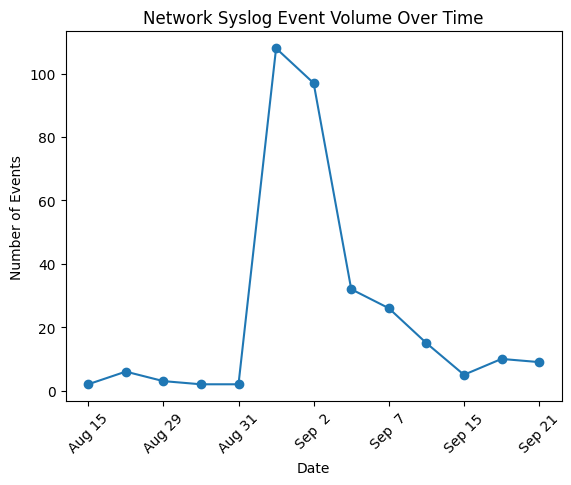

In [69]:
df["date"] = df["timestamp"].str.extract(
    r"^([A-Z][a-z]{2}\s+\d+)"
)

daily_events = df["date"].value_counts().sort_index()

daily_events.plot(kind="line", marker="o")
plt.xlabel("Date")
plt.ylabel("Number of Events")
plt.title("Network Syslog Event Volume Over Time")
plt.xticks(rotation=45)
plt.show()